# FinTech Customer Churn Prediction — Exploratory Data Analysis (EDA)

## Overview

Customer churn is an important business problem for financial institutions because losing existing customers can reduce revenue, increase acquisition costs, and weaken long-term customer relationships.

This notebook performs **Exploratory Data Analysis (EDA)** on the customer churn dataset to understand:

- The structure and quality of the data
- Customer demographics and banking characteristics
- The distribution of the churn target
- Patterns associated with customer churn
- Relationships between numerical and categorical variables
- Potential features that may be useful for subsequent machine learning models

### EDA workflow

1. Import libraries
2. Load the dataset
3. Initial Dataset Inspection
4. Data Dictionary
5. Descriptive Statistics
6. Data Quality Checks
7. Taregt Variable Analysis

### 1. Import Libraries

The following libraries are used for data manipulation, numerical analysis, visualization, and exploratory analysis.

- **Pandas** — data loading and manipulation
- **NumPy** — numerical operations
- **Matplotlib** — visualization
- **Seaborn** — statistical and business-oriented visualizations

In [12]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns when inspecting DataFrames.
pd.set_option("display.max_columns", None)

# Use a consistent visual style throughout the notebook.
sns.set_theme(style="whitegrid")

### 2. Load the Dataset

The dataset is stored in the project's `data/raw/` directory.

Keeping raw data separate from notebooks and processed data helps maintain a clean and reproducible project structure.


In [13]:
# Load the raw custoner churn dataset
DATA_PATH = "../Data/Raw/Churn_Modelling.csv"
df = pd.read_csv(DATA_PATH)

### 3. Initial Dataset Inspection

Before performing any cleaning or modeling, the first step is to understand the size, structure, data types, and sample records.

This initial inspection helps identify potential data-quality issues early and provides context for the rest of the analysis.


#### 3.1 Sample Records

`head()` displays the first five observations so we can visually inspect column names, data values, and the overall structure of individual customer records.


In [14]:
# display first 5 rows of dataset
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### 3.2 Dataset Dimensions

The shape of the DataFrame tells us how many customer records and features are available.

For this dataset, the initial inspection shows **10,000 rows and 14 columns**.


In [15]:
# Returns the number of rows and columns
df.shape

(10000, 14)

#### 3.3 Data Types and Non-Null Counts

`info()` provides a compact structural summary, including:

- Number of observations
- Column names
- Non-null counts
- Data types
- Approximate memory usage

This is useful for identifying columns that may require type conversion or missing-value treatment.


In [16]:
# Inspect column names, data types, non-null counts, and memory usage.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


### 4. Data Dictionary

The table below documents the business meaning and expected role of the main variables.

`RowNumber`, `CustomerId`, and `Surname` are identifying attributes rather than behavioral predictors. They are therefore candidates for exclusion from the machine-learning feature set later in the project.


| Feature | Type | Business Meaning | Modeling Role |
|---|---|---|---|
| RowNumber | Identifier | Dataset row identifier | Exclude |
| CustomerId | Identifier | Unique customer identifier | Exclude |
| Surname | Categorical / Identifier | Customer surname | Exclude |
| CreditScore | Numeric | Customer creditworthiness | Feature |
| Geography | Categorical | Customer location | Feature |
| Gender | Categorical | Customer gender | Feature |
| Age | Numeric | Customer age | Feature |
| Tenure | Numeric | Years with the bank | Feature |
| Balance | Numeric | Account balance | Feature |
| NumOfProducts | Numeric | Number of bank products | Feature |
| HasCrCard | Binary | Credit card ownership indicator | Feature |
| IsActiveMember | Binary | Active customer indicator | Feature |
| EstimatedSalary | Numeric | Estimated annual salary | Feature |
| Exited | Binary / Target | Customer churn indicator | Target |


### 5. Descriptive Statistics

Descriptive statistics provide an initial understanding of the distribution and range of numerical variables.

We will examine measures such as:

- Mean and median
- Standard deviation
- Minimum and maximum values
- Quartiles

These statistics help identify unusual ranges, highly variable features, and potential outliers that should be investigated during preprocessing.


In [17]:
# Generate descriptive statistics for numerical columns.
df. describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### 6. Data Quality Checks

Before interpreting patterns, we need to confirm whether the dataset contains missing values or duplicate records.

These checks are important because missing or duplicated observations can distort descriptive statistics and model training.

#### 6.1 Missing Values

The following check counts missing values in every column.

The current dataset contains **no missing values**, so no missing-value imputation is required at this stage.


In [18]:
# Count missing value in each column
# df.isnull().sum()
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [19]:
# Display only columns containing missing values
missing_values[missing_values > 0]

Series([], dtype: int64)

#### 6.2 Duplicate Records

Duplicate observations can cause certain customers to be over-represented during analysis or model training.

The current dataset contains **0 completely duplicated rows**.


In [20]:
# Count completely duplicated rows
df.duplicated().sum()

np.int64(0)

#### 6.3 Unique Values in Categorical Features

Checking unique values helps confirm that categorical variables contain expected categories and can also reveal unexpected labels or data-entry inconsistencies.


In [21]:
# Inspect unique values for the main categorical variables.
for column in ["Geography", "Gender"]:
    print(f"{column}: {df[column].unique()}")
    print()

Geography: <StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str



### 7. Target Variable Analysis (Customer Churn)
The target variable is `Exited`:

- `0` → Customer remained with the bank
- `1` → Customer exited / churned

Understanding the target distribution is essential before model development because an imbalanced target can affect model evaluation and the choice of performance metrics.


In [22]:
# Target Distribution
df["Exited"].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

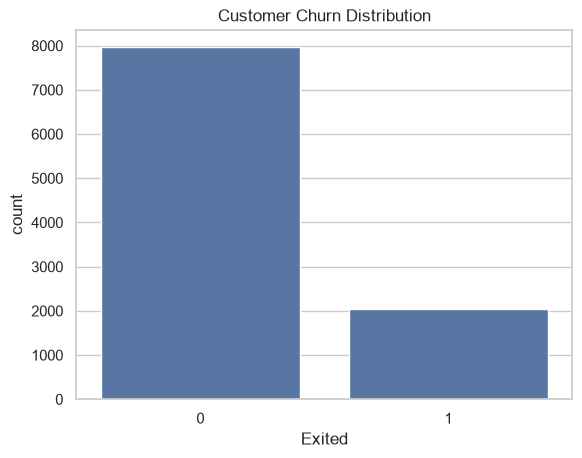

In [23]:
sns.countplot(data=df, x="Exited")
plt.title("Customer Churn Distribution")
plt.show()

So this gives me my first business KPI
Churn Rate = Churned Customers / Total Customers